<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/CIC_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File 'Obfuscated-MalMem2022.csv' not found. Please upload the dataset:


Saving Obfuscated-MalMem2022.csv to Obfuscated-MalMem2022.csv
Initial Dataset Shape: (58596, 57)
Dropped zero-variance columns (3): ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']
Cleaned Feature Matrix Shape: (58062, 52)
Target Classes (2): ['Benign' 'Malware']

--- Performance Metrics ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11613
   macro avg       1.00      1.00      1.00     11613
weighted avg       1.00      1.00      1.00     11613



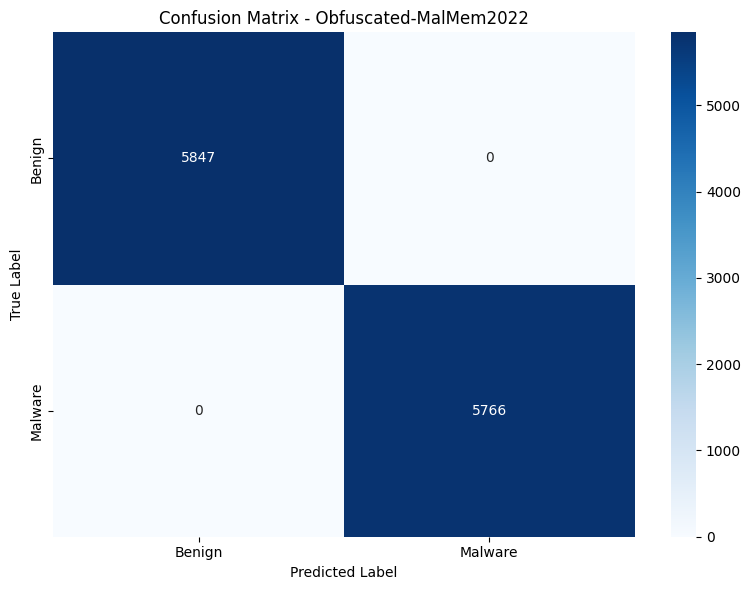

In [2]:
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------------------------------------------------
# 1. Robust File Path & Loading Resolution
# ---------------------------------------------------------
file_name = "Obfuscated-MalMem2022.csv"

if not os.path.exists(file_name):
    # Check for a compressed .zip version of the dataset
    if os.path.exists(f"{file_name}.zip"):
        print(f"Extracting {file_name}.zip...")
        with zipfile.ZipFile(f"{file_name}.zip", "r") as zip_ref:
            zip_ref.extractall(".")
    else:
        try:
            # Prompt file upload if running in Google Colab environment
            from google.colab import files

            print(
                f"File '{file_name}' not found. Please upload the dataset:"
            )
            uploaded = files.upload()
        except ImportError:
            # Perform recursive search across working subdirectories
            found_paths = [
                os.path.join(root, f)
                for root, _, files_list in os.walk(".")
                for f in files_list
                if f.lower() == file_name.lower()
            ]
            if found_paths:
                file_name = found_paths[0]
                print(f"Found dataset at path: {file_name}")
            else:
                raise FileNotFoundError(
                    f"Cannot locate '{file_name}' in current directory '{os.getcwd()}'. "
                    "Please place the dataset file in the execution directory."
                )

df = pd.read_csv(file_name)
print(f"Initial Dataset Shape: {df.shape}")

# ---------------------------------------------------------
# 2. Data Cleaning & Preprocessing
# ---------------------------------------------------------

# Remove exact duplicates and missing records
df = df.drop_duplicates().dropna()

# Identify target column
target_col = "Class" if "Class" in df.columns else "Category"

# Drop identifiers AND non-target label columns to avoid string scaling errors
non_feature_cols = ["Name", "Raw_filename", "filename"]
if target_col == "Class" and "Category" in df.columns:
    non_feature_cols.append("Category")
elif target_col == "Category" and "Class" in df.columns:
    non_feature_cols.append("Class")

cols_to_drop = [col for col in non_feature_cols if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Separate Features (X) and Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Ensure features are strictly numeric
X = X.select_dtypes(include=[np.number])

# Drop quasi-constant/zero-variance features
constant_features = [col for col in X.columns if X[col].std() == 0]
if constant_features:
    X = X.drop(columns=constant_features)
    print(
        f"Dropped zero-variance columns ({len(constant_features)}): {constant_features}"
    )

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Cleaned Feature Matrix Shape: {X.shape}")
print(
    f"Target Classes ({len(label_encoder.classes_)}): {label_encoder.classes_}"
)

# ---------------------------------------------------------
# 3. Train / Test Split & Feature Scaling
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 4. Model Training (Random Forest)
# ---------------------------------------------------------

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = clf.predict(X_test_scaled)

# ---------------------------------------------------------
# 5. Performance Evaluation & Visualization
# ---------------------------------------------------------

print("\n--- Performance Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix - Obfuscated-MalMem2022")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()